# Day 8 — Statistics & Probability Foundations
### Using the Titanic Dataset | scipy | seaborn | numpy

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import scipy

plt.style.use("dark_background")
sns.set_palette("husl")

df = pd.read_csv(r"C:\DS-AI-75d\titanic.csv")
ages = df["Age"].dropna().values
fares = df["Fare"].values

print(f"Pandas:     {pd.__version__}")
print(f"NumPy:      {np.__version__}")
print(f"SciPy:      {scipy.__version__}")
print(f"Dataset:    {df.shape}")
print(f"Ages available: {len(ages)}")
print("All good! Ready to go! ✅")

Pandas:     2.3.3
NumPy:      2.4.3
SciPy:      1.17.1
Dataset:    (891, 12)
Ages available: 714
All good! Ready to go! ✅


## 2. Descriptive Statistics
> Understanding the central tendency and spread of our data

In [4]:
print("=" * 45)
print("       DESCRIPTIVE STATISTICS - AGE")
print("=" * 45)
print(f"Count:        {len(ages)}")
print(f"Mean:         {np.mean(ages):.2f}")
print(f"Median:       {np.median(ages):.2f}")
print(f"Mode:         {stats.mode(ages).mode:.2f}")
print(f"Std Dev:      {np.std(ages):.2f}")
print(f"Variance:     {np.var(ages):.2f}")
print(f"Min:          {np.min(ages):.2f}")
print(f"Max:          {np.max(ages):.2f}")
print(f"Range:        {np.max(ages) - np.min(ages):.2f}")
print(f"Skewness:     {stats.skew(ages):.2f}")
print(f"Kurtosis:     {stats.kurtosis(ages):.2f}")

       DESCRIPTIVE STATISTICS - AGE
Count:        714
Mean:         29.70
Median:       28.00
Mode:         24.00
Std Dev:      14.52
Variance:     210.72
Min:          0.42
Max:          80.00
Range:        79.58
Skewness:     0.39
Kurtosis:     0.17


In [5]:
print("=" * 45)
print("       DESCRIPTIVE STATISTICS - FARE")
print("=" * 45)
print(f"Count:        {len(fares)}")
print(f"Mean:         {np.mean(fares):.2f}")
print(f"Median:       {np.median(fares):.2f}")
print(f"Std Dev:      {np.std(fares):.2f}")
print(f"Min:          {np.min(fares):.2f}")
print(f"Max:          {np.max(fares):.2f}")
print(f"Skewness:     {stats.skew(fares):.2f}")

       DESCRIPTIVE STATISTICS - FARE
Count:        891
Mean:         32.20
Median:       14.45
Std Dev:      49.67
Min:          0.00
Max:          512.33
Skewness:     4.78


## 3. Data Distributions & Visualisation

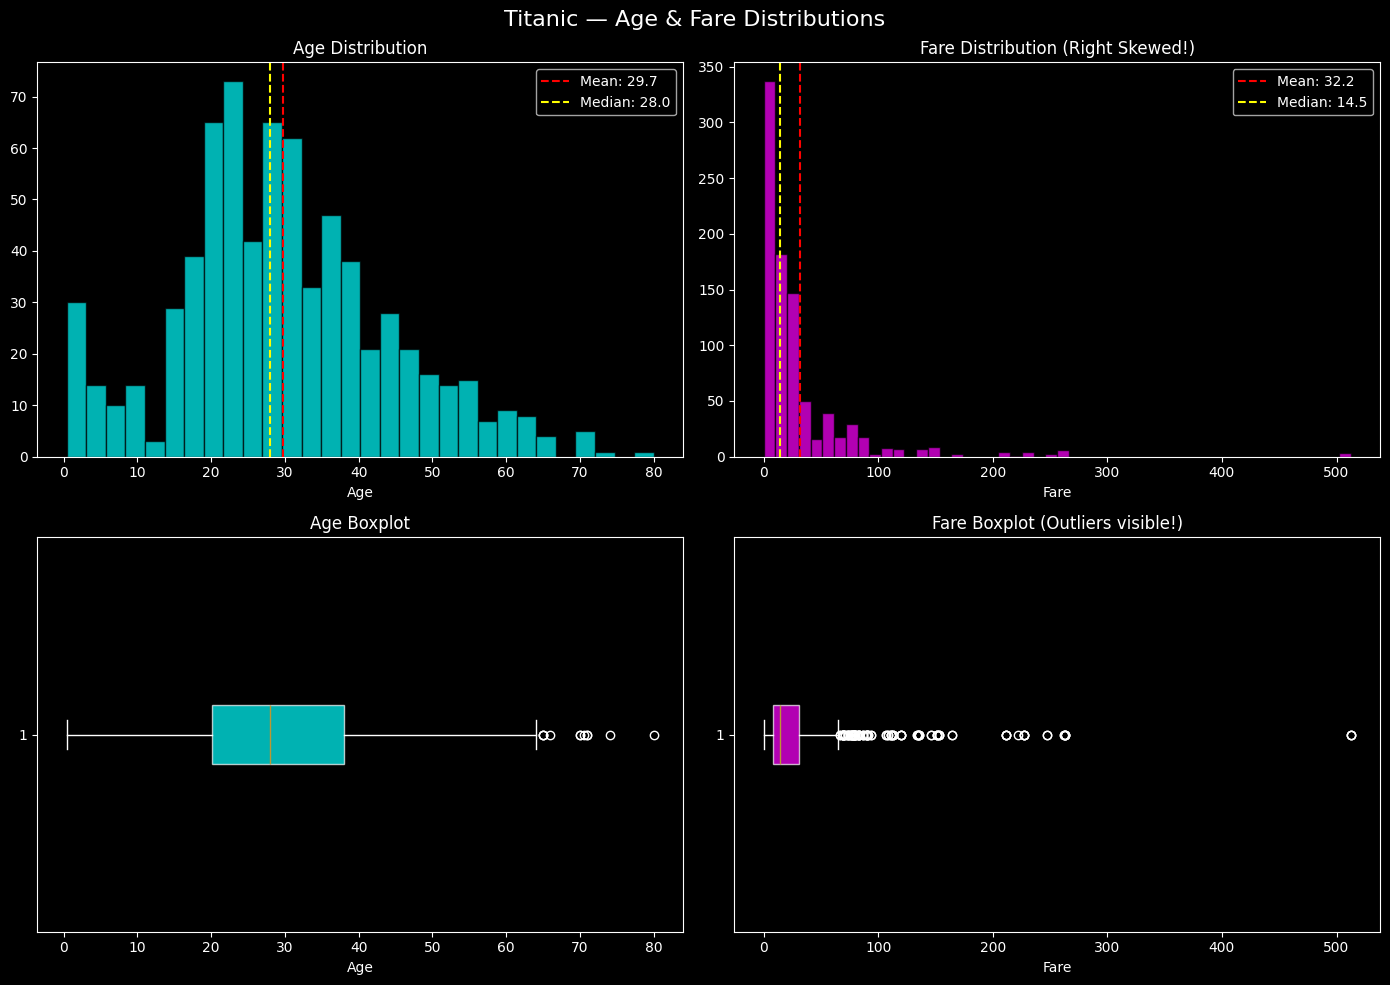

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Titanic — Age & Fare Distributions", fontsize=16)

# Age histogram
axes[0, 0].hist(ages, bins=30, color="cyan", edgecolor="black", alpha=0.7)
axes[0, 0].axvline(
    np.mean(ages), color="red", linestyle="--", label=f"Mean: {np.mean(ages):.1f}"
)
axes[0, 0].axvline(
    np.median(ages),
    color="yellow",
    linestyle="--",
    label=f"Median: {np.median(ages):.1f}",
)
axes[0, 0].set_title("Age Distribution")
axes[0, 0].set_xlabel("Age")
axes[0, 0].legend()

# Fare histogram
axes[0, 1].hist(fares, bins=50, color="magenta", edgecolor="black", alpha=0.7)
axes[0, 1].axvline(
    np.mean(fares), color="red", linestyle="--", label=f"Mean: {np.mean(fares):.1f}"
)
axes[0, 1].axvline(
    np.median(fares),
    color="yellow",
    linestyle="--",
    label=f"Median: {np.median(fares):.1f}",
)
axes[0, 1].set_title("Fare Distribution (Right Skewed!)")
axes[0, 1].set_xlabel("Fare")
axes[0, 1].legend()

# Age boxplot
axes[1, 0].boxplot(
    ages, vert=False, patch_artist=True, boxprops=dict(facecolor="cyan", alpha=0.7)
)
axes[1, 0].set_title("Age Boxplot")
axes[1, 0].set_xlabel("Age")

# Fare boxplot
axes[1, 1].boxplot(
    fares, vert=False, patch_artist=True, boxprops=dict(facecolor="magenta", alpha=0.7)
)
axes[1, 1].set_title("Fare Boxplot (Outliers visible!)")
axes[1, 1].set_xlabel("Fare")

plt.tight_layout()
plt.show()

## 4. Probability & Survival Analysis

In [7]:
print("=" * 45)
print("     SURVIVAL PROBABILITY BY CLASS")
print("=" * 45)

total = len(df)
survived = df["Survived"].sum()

print(f"\nOverall survival rate: {survived/total*100:.1f}%")
print()

for pclass in [1, 2, 3]:
    group = df[df["Pclass"] == pclass]
    rate = group["Survived"].mean() * 100
    count = len(group)
    print(f"Class {pclass}: {rate:.1f}% survived ({count} passengers)")

print()
# By gender
print("=" * 45)
print("     SURVIVAL PROBABILITY BY GENDER")
print("=" * 45)
for sex in ["female", "male"]:
    group = df[df["Sex"] == sex]
    rate = group["Survived"].mean() * 100
    print(f"{sex.capitalize()}: {rate:.1f}% survived")

     SURVIVAL PROBABILITY BY CLASS

Overall survival rate: 38.4%

Class 1: 63.0% survived (216 passengers)
Class 2: 47.3% survived (184 passengers)
Class 3: 24.2% survived (491 passengers)

     SURVIVAL PROBABILITY BY GENDER
Female: 74.2% survived
Male: 18.9% survived


## 5. Hypothesis Testing — t-test

In [8]:
# Did survivors and non-survivors have different ages?
survived_ages = df[df["Survived"] == 1]["Age"].dropna()
died_ages = df[df["Survived"] == 0]["Age"].dropna()

t_stat, p_value = stats.ttest_ind(survived_ages, died_ages)

print("=" * 45)
print("  HYPOTHESIS TEST: Age vs Survival")
print("=" * 45)
print(f"\nH0: No difference in age between survivors and non-survivors")
print(f"\nSurvivors  — Mean Age: {survived_ages.mean():.2f}")
print(f"Non-survivors — Mean Age: {died_ages.mean():.2f}")
print(f"\nt-statistic: {t_stat:.4f}")
print(f"p-value:     {p_value:.4f}")
print()
if p_value < 0.05:
    print("Result: SIGNIFICANT ✅ — Age DID affect survival!")
else:
    print("Result: NOT significant ❌ — Age had no effect on survival")

  HYPOTHESIS TEST: Age vs Survival

H0: No difference in age between survivors and non-survivors

Survivors  — Mean Age: 28.34
Non-survivors — Mean Age: 30.63

t-statistic: -2.0667
p-value:     0.0391

Result: SIGNIFICANT ✅ — Age DID affect survival!


## 6. Correlation Analysis

        CORRELATION MATRIX
          Survived  Pclass   Age  SibSp  Parch  Fare
Survived      1.00   -0.34 -0.08  -0.04   0.08  0.26
Pclass       -0.34    1.00 -0.37   0.08   0.02 -0.55
Age          -0.08   -0.37  1.00  -0.31  -0.19  0.10
SibSp        -0.04    0.08 -0.31   1.00   0.41  0.16
Parch         0.08    0.02 -0.19   0.41   1.00  0.22
Fare          0.26   -0.55  0.10   0.16   0.22  1.00


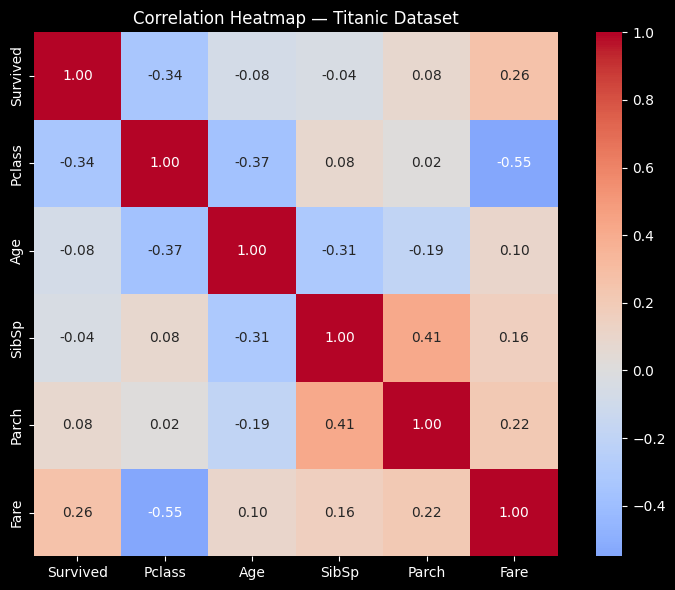

In [9]:
print("=" * 45)
print("        CORRELATION MATRIX")
print("=" * 45)

corr_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]
corr_matrix = df[corr_cols].corr()

print(corr_matrix.round(2))

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap — Titanic Dataset")
plt.tight_layout()
plt.show()

## 7. Key Takeaways — Day 8 🎯

### Statistics Concepts Learned
- **Mean vs Median** — Median is more honest for skewed data (Fare: Mean=32 vs Median=14!)
- **Skewness** — Age was mild (0.39), Fare was extreme (4.78) → right skewed
- **Std Dev & Variance** — How spread out data is from the mean
- **Kurtosis** — Measures the "peakedness" of a distribution

### Hypothesis Testing
- **t-test** — Compares means of two groups statistically
- **p-value** — Probability the result happened by chance (p<0.05 = significant)
- Age vs Survival was **statistically significant** (p=0.039) ✅

### Correlation
- Values range from **-1 to +1**
- Pclass & Survival: **-0.34** → Higher class = better survival
- Fare & Survival: **+0.26** → Higher fare = better survival
- Pclass & Fare: **-0.55** → Strongest relationship found

### Titanic Insights 🚢
- Only **38.4%** of passengers survived
- **1st class: 63%** vs **3rd class: 24%** survival
- **Women: 74.2%** vs **Men: 18.9%** survival
- Money and gender were the biggest survival factors

### Tools Used
- `numpy` — Descriptive statistics
- `scipy.stats` — t-test, skewness, kurtosis, mode
- `seaborn` — Heatmap visualisation
- `matplotlib` — Histograms, boxplots